# Customer Churn Classification

End-to-end pipeline on the Telco Customer Churn dataset: EDA, preprocessing, training two models (Logistic Regression and Random Forest), evaluation, and persistence of the best model.

## 1. Imports

In [13]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

## 2. Load dataset

In [20]:
import os
print(f"Current directory: {os.getcwd()}")
print(f"Files in current directory: {os.listdir('.')}")
print(f"Does data folder exist? {os.path.exists('data')}")

Current directory: /
Files in current directory: ['tmp', 'root', 'sbin', 'var', 'run', 'libx32', 'media', 'lib64', 'usr', 'srv', 'proc', 'mnt', 'bin', 'etc', 'home', 'sys', 'boot', 'dev', 'lib32', 'opt', 'lib', 'kaggle', '.dockerenv', 'tools', 'datalab', 'content', 'python-apt', 'python-apt.tar.xz']
Does data folder exist? False


In [25]:
import zipfile
import os
import pandas as pd

# Extract the downloaded zip file
with zipfile.ZipFile('/telco-customer-churn.zip', 'r') as zip_ref:
    zip_ref.extractall('/')

# List files to see what was extracted
print(os.listdir('/'))

# Read the CSV
df = pd.read_csv('/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

['tmp', 'root', 'sbin', 'var', 'run', 'libx32', 'media', 'lib64', 'usr', 'srv', 'proc', 'mnt', 'bin', 'etc', 'home', 'sys', 'boot', 'dev', 'lib32', 'opt', 'lib', 'telco-customer-churn.zip', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', 'kaggle', '.dockerenv', 'tools', 'datalab', 'content', 'python-apt', 'python-apt.tar.xz']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Basic EDA

In [26]:
print('Shape:', df.shape)
df.info()

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

In [27]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [28]:
df['Churn'].value_counts(normalize=True).round(3)

,proportion
Churn,
No,0.735
Yes,0.265


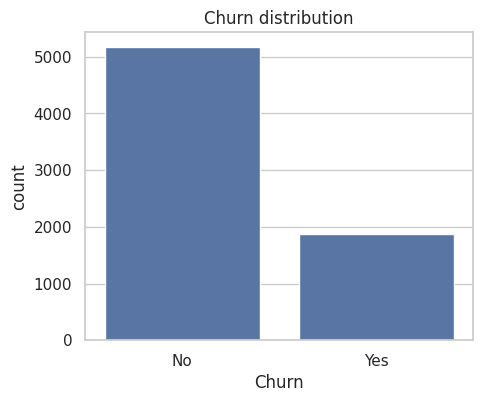

In [29]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Churn')
plt.title('Churn distribution')
plt.show()

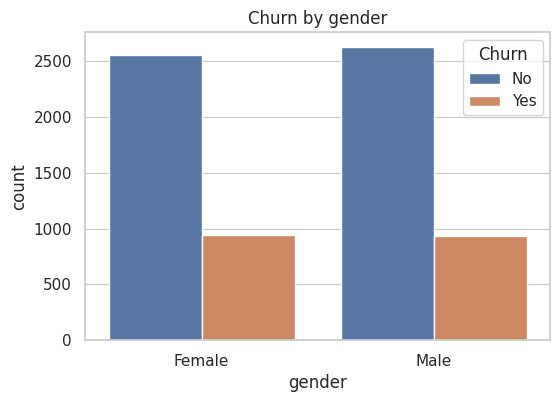

In [30]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='gender', hue='Churn')
plt.title('Churn by gender')
plt.show()

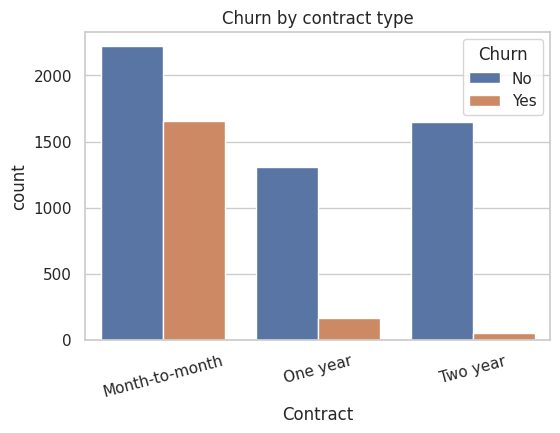

In [31]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by contract type')
plt.xticks(rotation=15)
plt.show()

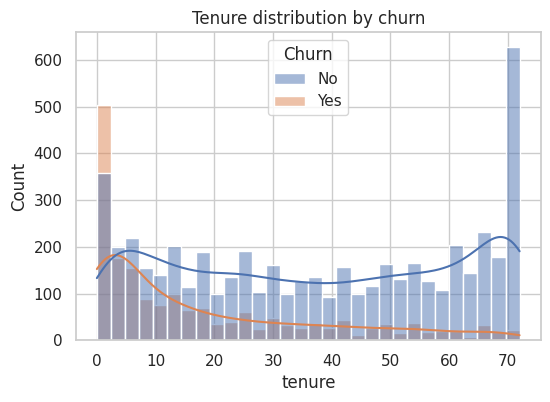

In [32]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Tenure distribution by churn')
plt.show()

## 4. Preprocessing

- Drop `customerID`
- Convert `TotalCharges` to numeric (ships as object with empty strings for new customers)
- Impute missing `TotalCharges` with the median
- Map `Churn` (Yes/No) to (1/0)
- Build a `ColumnTransformer` so the encoding/scaling travels with the fitted model.

In [33]:
df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [34]:
X = df.drop('Churn', axis=1)
y = df['Churn']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('Categorical:', categorical_cols)
print('Numeric:', numeric_cols)

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

## 5. Train / test split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape

((5634, 19), (1409, 19))

## 6. Logistic Regression

In [37]:
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

## 7. Random Forest

In [38]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    ))
])
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

## 8. Evaluation

In [39]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

log_results = evaluate_model(log_model, X_test, y_test)
rf_results = evaluate_model(rf_model, X_test, y_test)

results = pd.DataFrame({'LogReg': log_results, 'RandomForest': rf_results}).round(4)
results

,LogReg,RandomForest
Accuracy,0.8055,0.7750
Precision,0.6572,0.5979
Recall,0.5588,0.4652
F1 Score,0.6040,0.5233
ROC-AUC,0.8419,0.8187


### 5-fold cross-validated F1

In [40]:
log_cv = cross_val_score(log_model, X, y, cv=5, scoring='f1', n_jobs=-1)
rf_cv = cross_val_score(rf_model, X, y, cv=5, scoring='f1', n_jobs=-1)

print(f'Logistic Regression CV F1: {log_cv.mean():.4f} (+/- {log_cv.std():.4f})')
print(f'Random Forest CV F1:       {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})')

Logistic Regression CV F1: 0.6001 (+/- 0.0172)
Random Forest CV F1:       0.5473 (+/- 0.0220)


### ROC curves

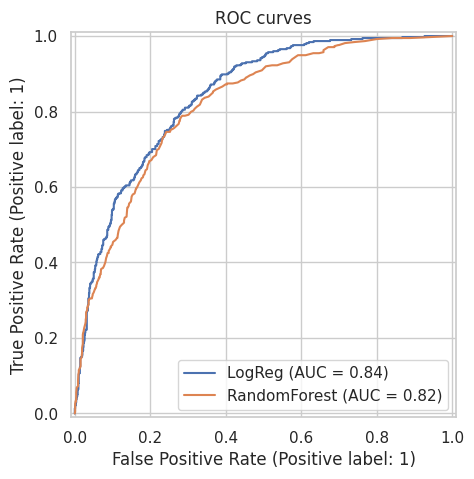

In [41]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(log_model, X_test, y_test, ax=ax, name='LogReg')
RocCurveDisplay.from_estimator(rf_model, X_test, y_test, ax=ax, name='RandomForest')
plt.title('ROC curves')
plt.show()

### Confusion matrix for the best model

Best by F1: LogReg


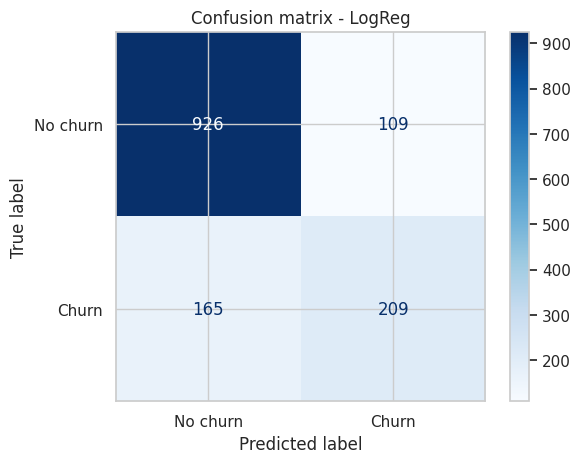

In [42]:
best_model = rf_model if rf_results['F1 Score'] >= log_results['F1 Score'] else log_model
best_name = 'RandomForest' if best_model is rf_model else 'LogReg'
print(f'Best by F1: {best_name}')

cm = confusion_matrix(y_test, best_model.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=['No churn', 'Churn']).plot(cmap='Blues')
plt.title(f'Confusion matrix - {best_name}')
plt.show()

## 9. Persist the best model

In [43]:
os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/churn_model.pkl')
print('Saved -> ../models/churn_model.pkl')

Saved -> ../models/churn_model.pkl
